In [1]:
import numpy as np
import numpy as np
import torch
from scipy import signal

import matplotlib.pyplot as plt

In [14]:
def load_train_test_all(data_folder: str, pars=np.arange(10, 27)):
    """
    Method to load all training and test data from participants [pars]
    :param data_folder:
    :param pars:
    :return:
    """

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    for i in pars:
        if i == 13:
            continue
        #print(f'{data_folder}/morph_dataset/par_{i}_mediapipe_dataset.pth')


        par_dataset = torch.load(f'{data_folder}/morph_dataset/par_{i}_mediapipe_dataset.pth',
                                 map_location=torch.device(device))


        for d in par_dataset.datasets:
            d.par = i

    return par_dataset
datapath = "E:\MoCap"
dataset = load_train_test_all(datapath, [14])
print(len(dataset))

26336


HERHEHRHEHREHERHEHRHREHRE ReadDatasetFiles(E:\MoCap/segmented), len=24565


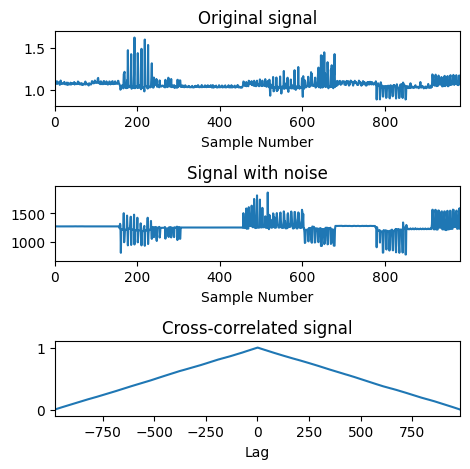

HERHEHRHEHREHERHEHRHREHRE ReadDatasetFiles(E:\MoCap/segmented), len=26336


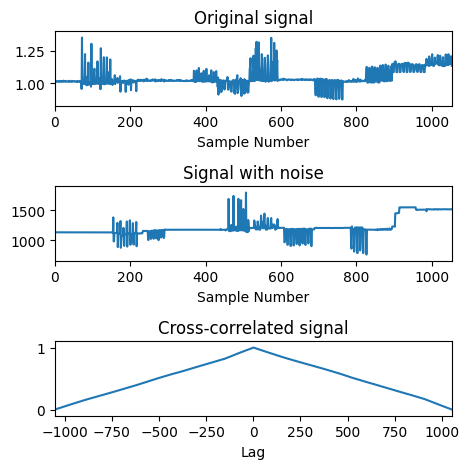

HERHEHRHEHREHERHEHRHREHRE ReadDatasetFiles(E:\MoCap/segmented), len=18533


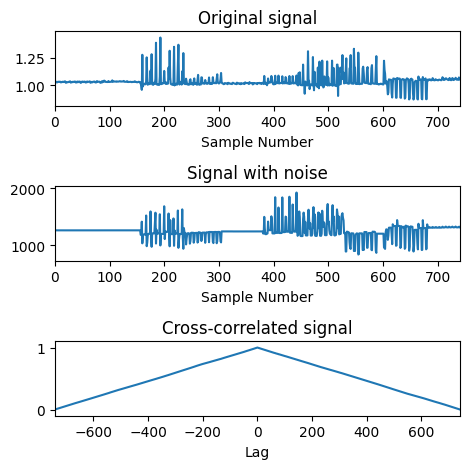

HERHEHRHEHREHERHEHRHREHRE ReadDatasetFiles(E:\MoCap/segmented), len=28529


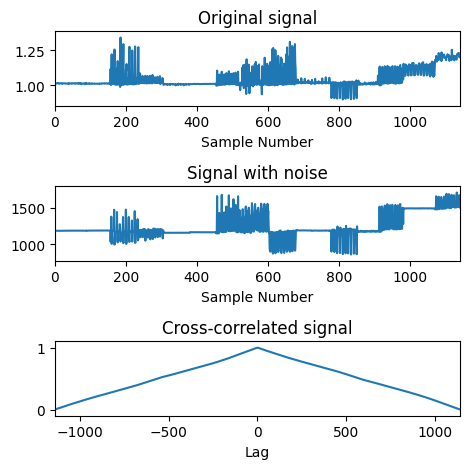

In [63]:
from skeletonMorphing.trainSkeletonMorphing import EveryNthSampler
import tqdm
from torch.utils.data import DataLoader

column_mapping = {
    'RShoulder': 'RSJC', # 12 - 0
    'LShoulder': 'LSJC', # 11 - 1
    'RElbow': 'REJC', # 14 - 2
    'LElbow': 'LEJC', # 13 - 3
    'RWrist': 'RWJC', # 16 - 4
    'LWrist': 'LWJC', # 15 - 5
    'RHip': 'RHJC', # 24 - 6
    'LHip': 'LHJC', # 23 - 7
    'RKnee': 'RKJC', # 26 - 8
    'LKnee': 'LKJC', # 25  - 9
    'RAnkle': 'RAJC', # 28 - 10
    'LAnkle': 'LAJC', # 27 - 11
    'RHeel': 'RHEE', # 30 - 12
    'LHeel': 'LHEE', # 29 - 13
    'RFootIndex': 'RTOE', # 32 - 14
    'LFootIndex': 'LTOE', # 31 - 15
}
maps = list(column_mapping.keys())


def get_graph(datapath, shuffle):
    data = []
    for par in [12, 14, 15, 16]:
        dataset = load_train_test_all(datapath, [par])
        sampler = EveryNthSampler(dataset, 25)
        dataloader = DataLoader(dataset, batch_size=30000, sampler=sampler)

        for step, batch in enumerate(dataloader):
            for t in range(6):
                for j in range(16):
                    # Access data for each batch
                    #print(batch)
                    pose_gt_batch = batch['pose_gt']
                    pose_inf_batch = batch['pose_inf']
                    #print(pose_gt_batch.shape)
                    #print(pose_inf_batch.shape)

                    x = np.arange(128) / 128

                    sig = torch.norm(pose_inf_batch, dim=3)
                    #print(sig.shape)
                    sig = sig[:, t, j]

                    sig_noise = torch.norm(pose_gt_batch, dim=2)
                    #print(sig_noise.shape)
                    sig_noise = sig_noise[:, j]

                    corr = signal.correlate(sig_noise, sig)

                    lags = signal.correlation_lags(len(sig), len(sig_noise))

                    corr /= np.max(corr)
                    data.append({
                        'Participant': par,
                        'Camera': t,
                        'Joint': maps[j],
                        'Max': np.max(corr),
                        'Lag Index': lags[np.argmax(corr)],
                    })
                    #print("MAX", np.max(corr), "Index", lags[np.argmax(corr)])

            fig, (ax_orig, ax_noise, ax_corr) = plt.subplots(3, 1, figsize=(4.8, 4.8))

            ax_orig.plot(sig)
            ax_orig.set_title('Original signal')
            ax_orig.set_xlabel('Sample Number')
            ax_noise.plot(sig_noise)
            ax_noise.set_title('Signal with noise')
            ax_noise.set_xlabel('Sample Number')
            ax_corr.plot(lags, corr)
            ax_corr.set_title('Cross-correlated signal')
            ax_corr.set_xlabel('Lag')
            ax_orig.margins(0, 0.1)

            ax_noise.margins(0, 0.1)

            ax_corr.margins(0, 0.1)

            fig.tight_layout()

            plt.show()
    return data

data = get_graph(datapath, False)

In [64]:
import pandas as pd
df = pd.DataFrame(data)
df

,Participant,Camera,Joint,Max,Lag Index
0,12,0,RShoulder,1.0,0
1,12,0,LShoulder,1.0,0
2,12,0,RElbow,1.0,0
3,12,0,LElbow,1.0,0
4,12,0,RWrist,1.0,0
...,...,...,...,...,...
379,16,5,LAnkle,1.0,0
380,16,5,RHeel,1.0,0
381,16,5,LHeel,1.0,0
382,16,5,RFootIndex,1.0,0


In [65]:
df[df['Lag Index'] != 0]

,Participant,Camera,Joint,Max,Lag Index
18,12,1,RElbow,1.0,-2
20,12,1,RWrist,1.0,-4
25,12,1,LKnee,1.0,-1
34,12,2,RElbow,1.0,-2
35,12,2,LElbow,1.0,1
...,...,...,...,...,...
351,16,3,LFootIndex,1.0,1
352,16,4,RShoulder,1.0,-1
354,16,4,RElbow,1.0,1
356,16,4,RWrist,1.0,5


In [61]:

for group_name, group_data in df.groupby([ "Joint", "Camera"]):
    print("Group:", group_name)
    print(group_data)

Group: ('LAnkle', 0)
     Participant  Camera   Joint  Max  Lag Index
11            12       0  LAnkle  1.0          0
107           14       0  LAnkle  1.0          0
203           15       0  LAnkle  1.0          0
299           16       0  LAnkle  1.0          0
Group: ('LAnkle', 1)
     Participant  Camera   Joint  Max  Lag Index
27            12       1  LAnkle  1.0          0
123           14       1  LAnkle  1.0          0
219           15       1  LAnkle  1.0        -32
315           16       1  LAnkle  1.0         29
Group: ('LAnkle', 2)
     Participant  Camera   Joint  Max  Lag Index
43            12       2  LAnkle  1.0          0
139           14       2  LAnkle  1.0          0
235           15       2  LAnkle  1.0          0
331           16       2  LAnkle  1.0          0
Group: ('LAnkle', 3)
     Participant  Camera   Joint  Max  Lag Index
59            12       3  LAnkle  1.0        -32
155           14       3  LAnkle  1.0          0
251           15       3  LAnkle  

In [ ]:


column_mapping = {
    'RShoulder': 'RSJC', # 12 - 0
    'LShoulder': 'LSJC', # 11 - 1
    'RElbow': 'REJC', # 14 - 2
    'LElbow': 'LEJC', # 13 - 3
    'RWrist': 'RWJC', # 16 - 4
    'LWrist': 'LWJC', # 15 - 5
    'RHip': 'RHJC', # 24 - 6
    'LHip': 'LHJC', # 23 - 7
    'RKnee': 'RKJC', # 26 - 8
    'LKnee': 'LKJC', # 25  - 9
    'RAnkle': 'RAJC', # 28 - 10
    'LAnkle': 'LAJC', # 27 - 11
    'RHeel': 'RHEE', # 30 - 12
    'LHeel': 'LHEE', # 29 - 13
    'RFootIndex': 'RTOE', # 32 - 14
    'LFootIndex': 'LTOE', # 31 - 15
}
maps = list(column_mapping.keys())

def gransk_nøyere(batch, cam, joint):
    pose_gt_batch = batch['pose_gt']
    pose_inf_batch = batch['pose_inf']
    #sig = torch.norm(pose_inf_batch, dim=3)
    print("Cam", cam, "Joint", maps[joint],  "Gransker nøyere for XYZ")
    for i in range(3):
        sig = pose_inf_batch[:, cam, joint,i]

        #sig_noise = torch.norm(pose_gt_batch, dim=2)
        sig_noise = pose_gt_batch[:, joint,i]

        corr = signal.correlate(sig_noise, sig)

        lags = signal.correlation_lags(len(sig), len(sig_noise))

        corr /= np.max(corr)


        print(i, np.max(corr), lags[np.argmax(corr)])
        print("___________________________________________________________")




def get_graph(dataset, cam, joint):

    dataloader = DataLoader(dataset, batch_size=10000, shuffle=True)
    l = []
    c = []
    for step, batch in enumerate(dataloader):
        # Access data for each batch
        #print(batch)

        pose_gt_batch = batch['pose_gt']
        pose_inf_batch = batch['pose_inf']

        sig = torch.norm(pose_inf_batch, dim=3)
        sig = sig[:, cam, joint]

        sig_noise = torch.norm(pose_gt_batch, dim=2)
        sig_noise = sig_noise[:, joint]

        corr = signal.correlate(sig_noise, sig)

        lags = signal.correlation_lags(len(sig), len(sig_noise))

        corr /= np.max(corr)

        c.append(np.max(corr))
        l.append(lags[np.argmax(corr)])
        x = 0
        y = 0
        z = 0
        axes = [x, y, z]
        for i, axis in enumerate(axes):
            sig = pose_inf_batch[:, cam, joint, i]

            sig_noise = pose_gt_batch[:, joint, i]

            corr = signal.correlate(sig_noise, sig)

            lags = signal.correlation_lags(len(sig), len(sig_noise))

            corr /= np.max(corr)

            axes[i] = lags[np.argmax(corr)]

        #if lags[np.argmax(corr)] != 0:
            #gransk_nøyere(batch, cam, joint)

    #print("Participant:", par, " Camera", camera, " joint", maps[joint])
    #print("MAX", np.mean(c), "Index", np.mean(l))
    #print("___________________________________________________________")
    return np.mean(c), np.mean(l), axes[0], axes[1], axes[2]

data = []
for i in tqdm.tqdm(range(12, 17)):
    if i == 13:
        continue
    dataset = load_train_test_all(datapath, [i])


    print("Participant: ", i)
    for cam in range(6):
        print("Cam: ", cam)
        for j in range(16):
            c, l, x, y, z = get_graph(dataset, cam, j)
            if l != 0:
                #print("Participant:", i, " Camera", cam, " joint", maps[j])
                #print("MAX", c, "Index", l)
                #print("___________________________________________________________")
                data.append({
                    'Participant': i,
                    'Camera': cam,
                    'Joint': maps[j],
                    'Max': c,
                    'Index': l,
                    'X' : x,
                    'Y' : y,
                    'Z' : z
                })

#df = pd.DataFrame(data)



In [ ]:
df = pd.DataFrame(data)
df

In [ ]:
data_2 = []

def load_train_test_all(data_folder: str, pars=np.arange(10, 27), val = False):
    """
    Method to load all training and test data from participants [pars]
    :param data_folder:
    :param pars:
    :return:
    """

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    for i in pars:
        if i == 13:
            continue
        #print(f'{data_folder}/morph_dataset/par_{i}_mediapipe_dataset.pth')


        par_dataset = torch.load(f'{data_folder}/morph_dataset/par_{i}_mediapipe_dataset.pth',
                                 map_location=torch.device(device)).get_train_test()[int(val)]


        for d in par_dataset.datasets:
            d.par = i

    return par_dataset
datapath = "E:\MoCap"
dataset = load_train_test_all(datapath, [12])
print(len(dataset))
#### Only test Validation
for i in tqdm.tqdm(range(12, 17)):
    for val in range(2):

        if i == 13:
            continue
        dataset = load_train_test_all(datapath, [i], val)

        print("Participant: ", i)
        for cam in range(6):
            print("Cam: ", cam)
            for j in range(16):
                c, l, x, y, z = get_graph(dataset, cam, j)

                data_2.append({
                        'Participant': i,
                        'Camera': cam,
                        'Joint': maps[j],
                        'Max': c,
                        'Index': l,
                        'X' : x,
                        'Y' : y,
                        'Z' : z,
                        'Validation_set' : bool(val)
                    })
                #if l != 0:
                    #print("Participant:", i, " Camera", cam, " joint", maps[j])
                    #print("MAX", c, "Index", l)
                    #print("___________________________________________________________")



In [ ]:
df = pd.DataFrame(data_2)
df

In [ ]:
df[df['Validation_set'] == True]